In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import ParameterGrid

from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv(r"c:\Users\v_bha\Downloads\Wholesale_Data_with_Missing_Values (2).csv")

print(data)

     Channel  Region    Fresh     Milk  Grocery   Frozen  Detergents_Paper  \
0        2.0     3.0  12669.0   9656.0   7561.0    214.0            2674.0   
1        2.0     3.0   7057.0   9810.0   9568.0   1762.0            3293.0   
2        2.0     3.0   6353.0   8808.0   7684.0   2405.0            3516.0   
3        1.0     3.0  13265.0   1196.0   4221.0   6404.0             507.0   
4        2.0     3.0  22615.0   5410.0   7198.0   3915.0            1777.0   
..       ...     ...      ...      ...      ...      ...               ...   
435      1.0     3.0  29703.0  12051.0      NaN  13135.0             182.0   
436      1.0     3.0  39228.0   1431.0    764.0   4510.0               NaN   
437      2.0     3.0  14531.0  15488.0  30243.0    437.0           14841.0   
438      1.0     3.0  10290.0   1981.0   2232.0      NaN             168.0   
439      1.0     3.0   2787.0   1698.0   2510.0     65.0             477.0   

     Delicassen  
0        1338.0  
1        1776.0  
2        

In [3]:
print(data.isnull().sum())

Channel             22
Region              21
Fresh               22
Milk                25
Grocery             17
Frozen              24
Detergents_Paper    25
Delicassen          14
dtype: int64


In [4]:
#hndling missing values

fill_missing_values = SimpleImputer(strategy = "mean")

data = fill_missing_values.fit_transform(data)

In [5]:
#now scaling for the columns

scaling = StandardScaler()

data = scaling.fit_transform(data)

In [6]:
#to find the best values for the k we use elbow method



wcss = []

for i in range(1,21):
    #this n_cluster means no if clusters
    #this init means first we should pick random cetrooids so it help there are 2 way("k-meam++" and "random")
    #this n_init = 10 means it run the init = "k+mean++" 10 times the chosee the cetorid with least wcss
    #this max_iter we keep updated the cetorid as much as possbile right so even after doing this may time it stops do 
    #this tol(means tolerance it like the distnace b/w prv centoid and curr centroic and ) this 1e-4 values is somethingl ike 0.0001 like if the differce  is less then this is 0.001 it stops

    model = KMeans(n_clusters = i,init = "k-means++",n_init = 10,max_iter = 300,tol = 1e-4,random_state = 100)
    model.fit(data)
    wcss.append(model.inertia_)#this inertia means wcss values for each k value


print(wcss)

[3520.0, 2629.995103581736, 2270.599956080441, 1929.6895781682726, 1616.232871128904, 1396.7700189757338, 1237.3162080971474, 1121.4894893687685, 1074.8921675170473, 979.0219317401067, 910.8245608791334, 878.4023000094123, 797.4070883670587, 766.5105589374559, 738.8698776989448, 687.2665122598623, 677.3303868290604, 634.232885997302, 611.2800065479278, 585.0847442520128]


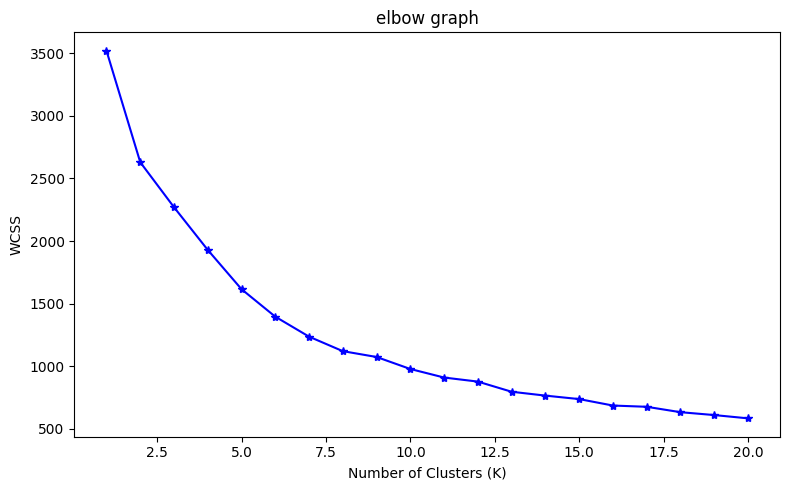

In [7]:
# we can plot this elbow curve

#this elbow graphs helps to check manully what the best values for k

plt.figure(figsize = (8,5))

plt.plot(range(1,21),wcss,marker = "*",color = "blue")
plt.title("elbow graph")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()

In [8]:
#Silhouette Score this is used to measuer how good the clustring like it ranges from 1 to -1 1 means good and 0 mean overlapping -1 means worst clustring

silhouette_scores = []

data = pd.DataFrame(data)

for i in range(2,21):
    model = KMeans(n_clusters = i,init = "k-means++",n_init = 10,max_iter = 300,tol = 1e-4,random_state = 100)
    output = model.fit_predict(data)#for this we get whchihc data belomg to whcih cluster

    

    score = silhouette_score(data,output)#this give the silhouette_score score for ever k values

    silhouette_scores.append(score)


print(silhouette_scores)

[0.35840693400184037, 0.37452632069622116, 0.35162661290978126, 0.3352538303789513, 0.3425175656418879, 0.34735336610727113, 0.3483151948126217, 0.34062253512361046, 0.35513266304111935, 0.34444940898831955, 0.315372713010216, 0.3097555933437858, 0.3134873499594662, 0.23600578859700622, 0.26893049238095984, 0.24060788343833475, 0.2694745199643118, 0.24593591913639462, 0.22208871299339983]


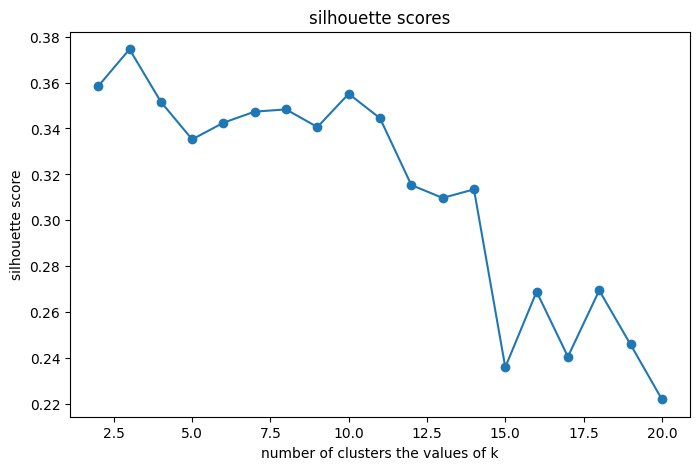

In [9]:
# Plot Silhouette Scores

plt.figure(figsize=(8,5))

plt.plot(range(2,21),silhouette_scores,marker='o')

plt.title("silhouette scores")
plt.xlabel("number of clusters the values of k")
plt.ylabel("silhouette score")

plt.show()

In [10]:
#the best k values is 

best_k_value = silhouette_scores.index(max(silhouette_scores)) + 2 #+2 becuse we skipped that 0 and 1 in clutsers so got get the values of k

print(best_k_value)

3


In [11]:
print(type(data))

#conver this ndarray to dataframe

data = pd.DataFrame(data)

<class 'pandas.core.frame.DataFrame'>


In [12]:
#now main model

final_model = KMeans(n_clusters = best_k_value,init = "k-means++",n_init = 10,max_iter = 300,tol = 1e-4,random_state = 100)


clusters = final_model.fit_predict(data)

data['Cluster'] = clusters


print(data)

            0         1         2         3             4             5  \
0    1.469370  0.598072  0.063949  0.559659 -3.563282e-02 -6.023675e-01   
1    1.469370  0.598072 -0.387722  0.581626  1.858393e-01 -2.780913e-01   
2    1.469370  0.598072 -0.444382  0.438702 -2.205979e-02 -1.433951e-01   
3   -0.716383  0.598072  0.111917 -0.647058 -4.042012e-01  6.943185e-01   
4    1.469370  0.598072  0.864433 -0.045982 -7.568981e-02  1.729208e-01   
..        ...       ...       ...       ...           ...           ...   
435 -0.716383  0.598072  1.434897  0.901277 -1.003626e-16  2.104334e+00   
436 -0.716383  0.598072  2.201498 -0.613538 -7.856806e-01  2.975619e-01   
437  1.469370  0.598072  0.213808  1.391524  2.467322e+00 -5.556533e-01   
438 -0.716383  0.598072 -0.127520 -0.535087 -6.236871e-01  9.526083e-17   
439 -0.716383  0.598072 -0.731384 -0.575454 -5.930098e-01 -6.335801e-01   

            6         7  Cluster  
0   -0.063225 -0.066555        2  
1    0.067877  0.089568      

In [13]:
print(final_model.cluster_centers_)#this gives the all the centroids for each clusters

print(final_model.inertia_)

final_Silhouette_score = silhouette_score(data,output)

print(final_Silhouette_score)#ParameterGrid


[[-0.45255255  0.47689629  2.98349281  0.60730514  0.55136715  3.52825052
  -0.14178228  3.3088638 ]
 [-0.6377869  -0.06014052  0.01603996 -0.35261695 -0.44362092  0.00479962
  -0.43314523 -0.1415212 ]
 [ 1.4258328   0.09211447 -0.27803089  0.71843723  0.92118156 -0.29793958
   0.95484669  0.03859061]]
2270.599956080441
0.221736519974028


In [14]:
#ParameterGrid


parmeters = {"n_clusters" : [2,3,4,5,6,7,8],"init" : ["k-means++","random"],"n_init" : [10,20,30],"max_iter" : [300,500,700]}

grid = ParameterGrid(parmeters)#this ParameterGrid helps to get all the combinations of the paramters we pass ever combinations

for i in grid:
    print(i)

{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 20}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 30}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 10}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 20}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 30}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 10}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 20}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 30}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5, 'n_init': 10}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5, 'n_init': 20}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5, 'n_init': 30}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6, 'n_init': 10}
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6, 'n_init': 20}
{'init': 'k-means++'

In [16]:
data.columns = data.columns.astype(str)

In [17]:
#we do hyperparameter tuning


pramters = {"n_clusters" : [2,3,4,5,6,7,8],"init" : ["k-means++","random"],"n_init" : [10,20,30],"max_iter" : [300,500,700]}

# grid = ParameterGrid(parmeters)#this ParameterGrid helps to get all the combinations of the paramters we pass ever combinations

best_score = -1
best_paramters = None
best_model = None

for i in ParameterGrid(parmeters):

    curr_best_model = KMeans(n_clusters = i["n_clusters"] ,init = i["init"] ,n_init = i["n_init"] ,max_iter = i["max_iter"],tol = 1e-4,random_state = 100)

    output = curr_best_model.fit_predict(data)

    score = silhouette_score(data,output)

    if score > best_score:

        best_score = score
        best_paramters = i
        best_model = curr_best_model



print(best_score)
print(best_paramters)
print(best_model)

0.38726086335177545
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 10}
KMeans(n_clusters=4, n_init=10, random_state=100)


In [18]:
#best model after clustring

best_model_after_tuning = KMeans(n_clusters=best_paramters["n_clusters"],init=best_paramters["init"],n_init=best_paramters["n_init"],max_iter=best_paramters["max_iter"],tol=1e-4,random_state=42,
)


best_model_prediction = best_model_after_tuning.fit_predict(data)


tuing_model_Silhouette_score =silhouette_score(data,best_model_prediction)

print(tuing_model_Silhouette_score)

0.3820208156008479
